# 450 vecinos invisibles dentro de una vaca

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 120px
:align: center
:::

Cada vez que una vaca eructa, sale metano. Los rumiantes producen alrededor del 14–30% del metano antropogénico — y dentro de su panza vive una comunidad microbiana enorme que decide cuánto sale.

Hasta ahora, los protistas de esa comunidad (los ciliados del rumen) casi no tenían genomas secuenciados. Este equipo catalogó **450** de un solo golpe — 87% nuevos para la ciencia — y encontró que un grupo en particular — el que carga una organela llamada hidrogenobody (HB) — es el que más promueve la metanogénesis.

📄 **Paper**: [Rumen ciliates modulate methane emissions in ruminants](https://doi.org/10.1126/science.adv4244) · *Science, 2026*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-30-ciliados-rumen-metano/notebook.ipynb)

## Por qué importa

El rumen de una vaca es un fermentador microbiano gigante. Bacterias, arqueas y ciliados (eucariotas unicelulares) trabajan juntos para digerir celulosa — y como subproducto sale H₂ que las arqueas convierten en CH₄.

Las bacterias del rumen tienen miles de genomas catalogados. Los ciliados, casi ninguno: son grandes (≈100 µm), eucariotas, difíciles de cultivar y de secuenciar. Sin sus genomas, era imposible saber **cuáles** ciliados promueven más metano y por qué.

Veamos qué encontró el equipo cuando finalmente abrió esa caja negra.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_CILIADOS_TOTAL = 450        # genomas catalogados
PCT_NOVEDOSOS = 87            # % nuevos para la ciencia
COLOR_DATOS = '#2563EB'       # azul CaM
COLOR_ALERTA = '#DC2626'      # rojo CaM
COLOR_VEST = '#7C3AED'        # violeta — Vestibuliferida (más HB)
COLOR_ENTO = '#059669'        # verde — Entodiniomorphida (menos HB)
FUENTE_PAPER = 'Fuente: Xie et al. (2026), Science | DOI: 10.1126/science.adv4244'

# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de datasets
datos_dir = 'datos' if os.path.exists('datos/ciliados_450_metadata.csv') else '/home/jupyter/datos'
ciliados = pd.read_csv(f'{datos_dir}/ciliados_450_metadata.csv')
archaea = pd.read_csv(f'{datos_dir}/archaea_158.csv')
bacterias = pd.read_csv(f'{datos_dir}/bacteria_phyla_resumen.csv')
hb_split = pd.read_csv(f'{datos_dir}/hb_split_ordenes.csv')

# Extraer orden taxonómico
ciliados['orden'] = ciliados['taxonomy'].str.extract(r'o__([^;]+)')

print(f'Ciliados:   {len(ciliados):>5} genomas')
print(f'Arqueas:    {len(archaea):>5} genomas (todas metanógenas: {archaea["is_methanogen"].all()})')
print(f'Bacterias:  {bacterias["n_genomes"].sum():>5} genomas en {len(bacterias)} phyla')
print(f'Tamaño catálogo total: {len(ciliados) + len(archaea) + bacterias["n_genomes"].sum():,} genomas')

Ciliados:     450 genomas
Arqueas:      158 genomas (todas metanógenas: True)
Bacterias:  12540 genomas en 31 phyla
Tamaño catálogo total: 13,148 genomas


## Aquí está.

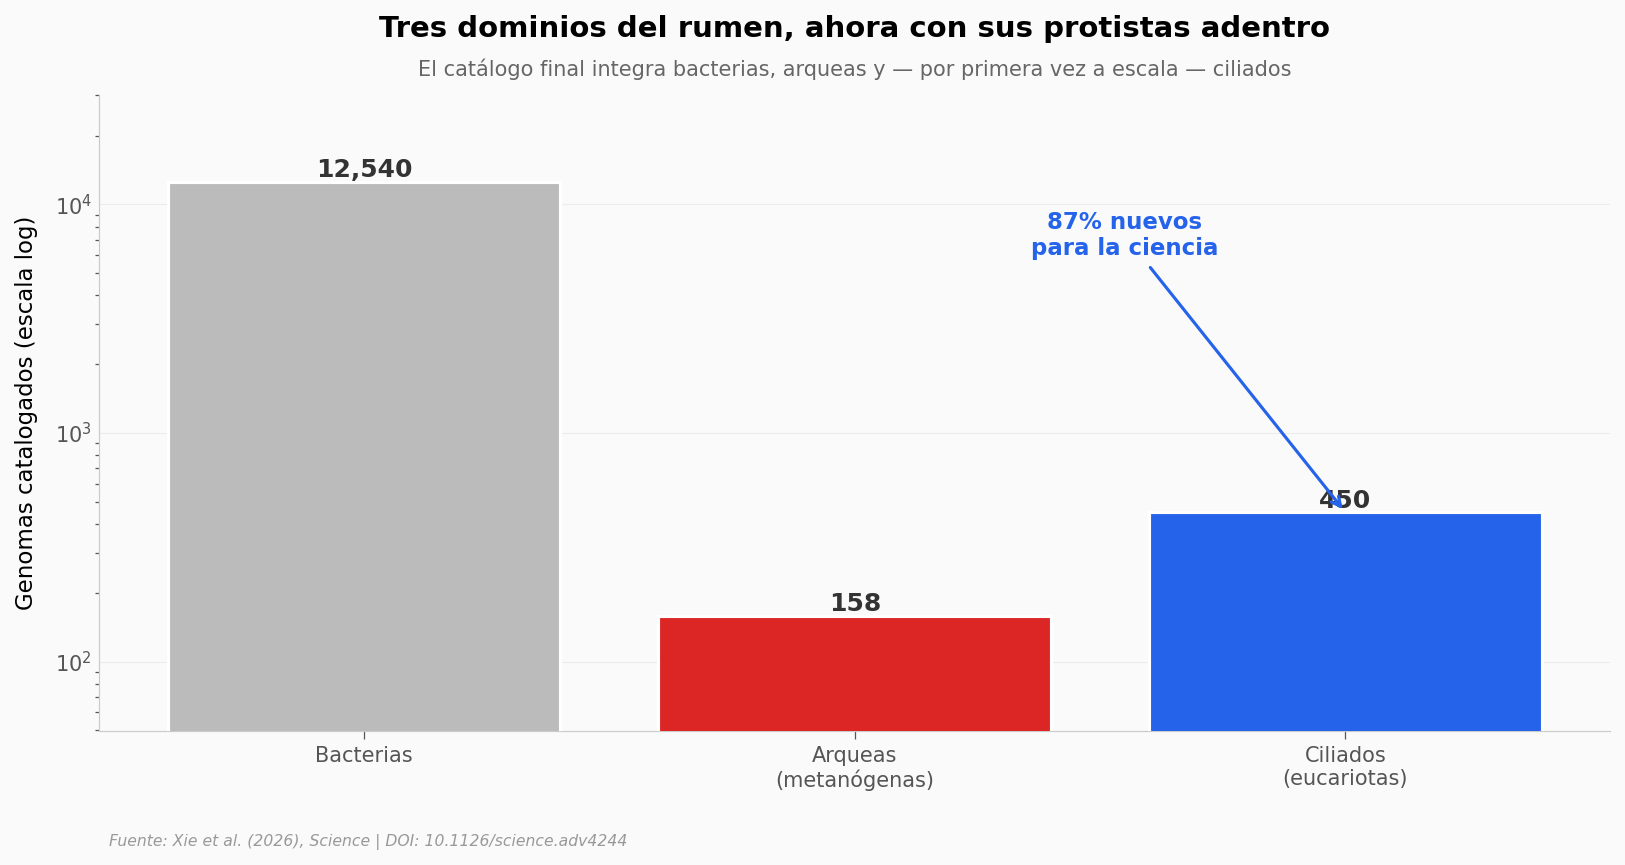

In [2]:
# Gráfica hero: tres dominios del rumen, lado a lado
fig, ax = plt.subplots(figsize=(13, 5.5))

dominios = ['Bacterias', 'Arqueas\n(metanógenas)', 'Ciliados\n(eucariotas)']
n_genomas = [bacterias['n_genomes'].sum(), len(archaea), len(ciliados)]
colores = ['#BBBBBB', COLOR_ALERTA, COLOR_DATOS]

bars = ax.bar(dominios, n_genomas, color=colores, edgecolor='white', linewidth=1.5, zorder=3)

# Etiqueta encima de cada barra
for bar, n in zip(bars, n_genomas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
            f'{n:,}', ha='center', fontsize=12, fontweight='bold', color='#333333')

# Anotación inline destacando el dato nuevo
ax.annotate(f'87% nuevos\npara la ciencia',
            xy=(2, len(ciliados)), xytext=(1.55, 6000),
            fontsize=11, fontweight='bold', color=COLOR_DATOS, ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))

ax.set_yscale('log')
ax.set_ylabel('Genomas catalogados (escala log)', fontsize=11)
ax.set_title('Tres dominios del rumen, ahora con sus protistas adentro',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El catálogo final integra bacterias, arqueas y — por primera vez a escala — ciliados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_ylim(50, 30000)
fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_tres_dominios.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que llama la atención

Bacterias y arqueas ya tenían miles y cientos de genomas en bases públicas. Los ciliados eran la pieza ausente: solo unos pocos genomas dispersos antes de este trabajo.

El salto cuantitativo es enorme — pasamos de tener fotos sueltas de algunos ciliados a tener un atlas. Y el dato más fuerte está en la flecha: la inmensa mayoría de esos 450 genomas son **completamente nuevos**. Especies que nadie había secuenciado antes, viviendo en una vaca que cualquiera puede ver.

## Quiénes son los 450

Los ciliados del rumen se reparten en dos órdenes principales. Las proporciones importan — pero como veremos después, no son lo mismo que la **influencia** sobre el metano.

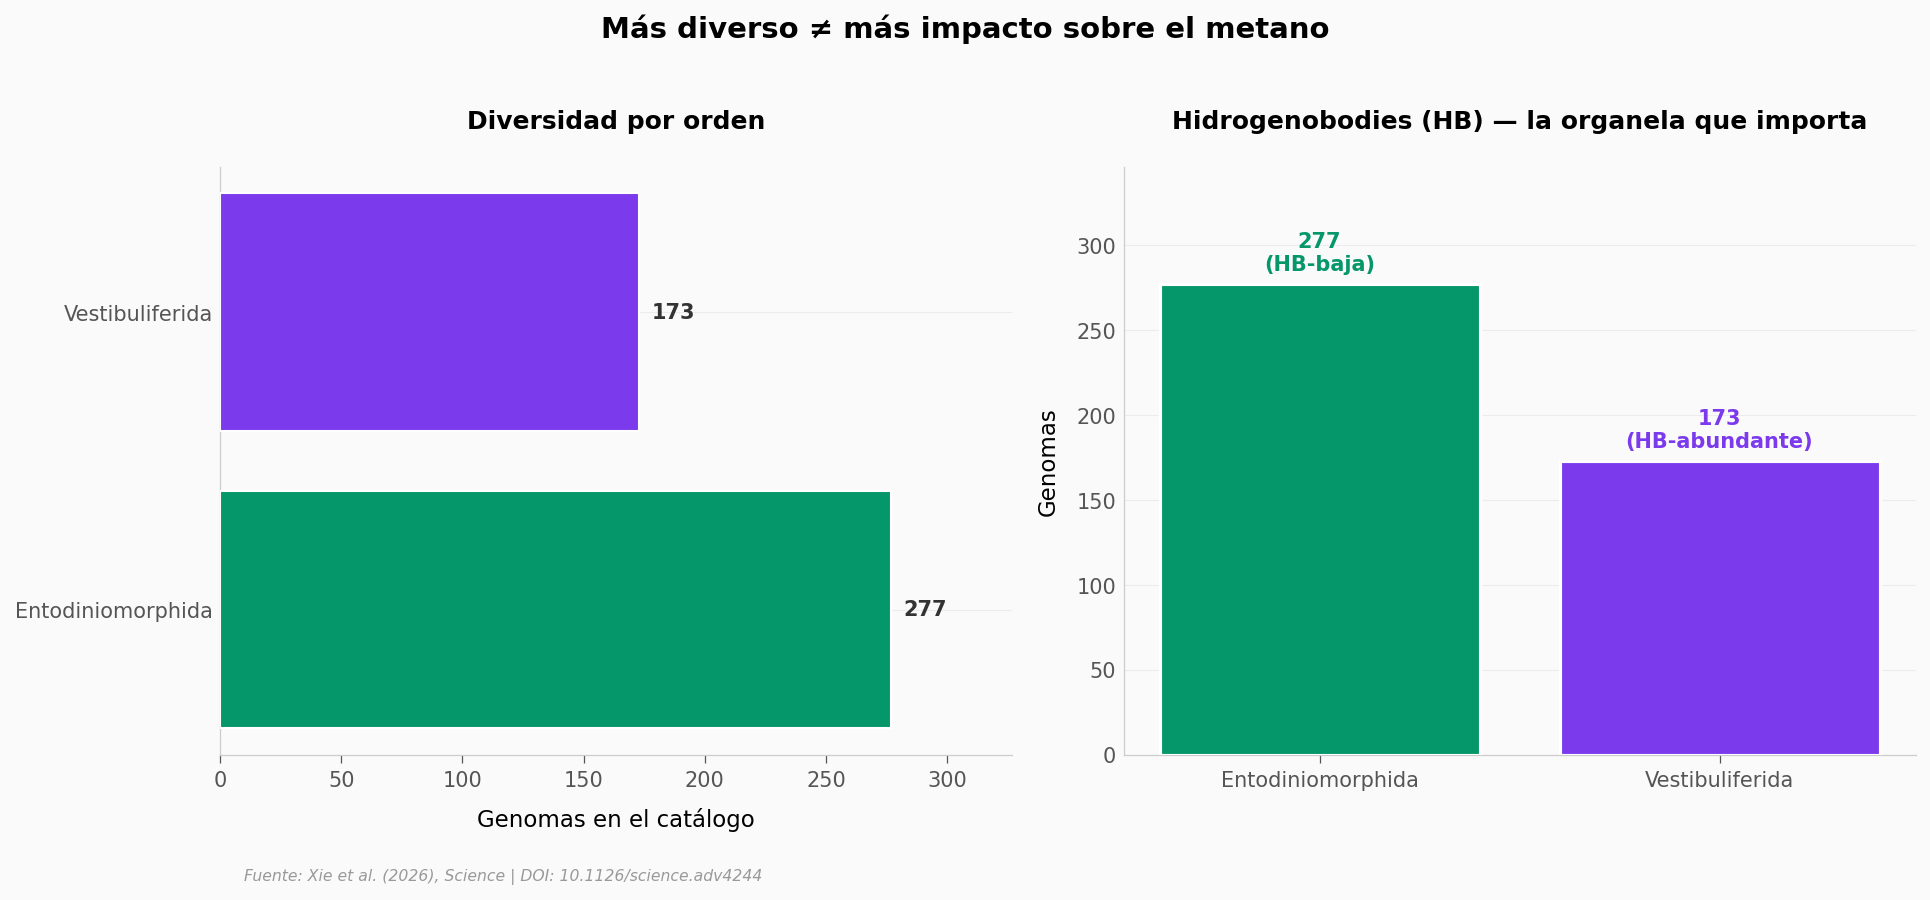

Vestibuliferida: 173 genomas (HB-abundante)
Entodiniomorphida: 277 genomas (HB-baja)
Ratio Ento/Vest: 1.60× — Entodiniomorphida es más diverso


In [3]:
# Distribución por orden taxonómico
order_counts = ciliados['orden'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel izquierdo: counts por orden
ax = axes[0]
colors_orden = [COLOR_ENTO if o == 'Entodiniomorphida'
                else COLOR_VEST if o == 'Vestibuliferida'
                else '#BBBBBB' for o in order_counts.index]
bars = ax.barh(order_counts.index, order_counts.values,
               color=colors_orden, edgecolor='white', linewidth=1, zorder=3)
for bar, val in zip(bars, order_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10, fontweight='bold', color='#333333')

ax.set_xlabel('Genomas en el catálogo', fontsize=11)
ax.set_title('Diversidad por orden',
             fontsize=12, fontweight='bold', pad=18)
ax.set_xlim(0, max(order_counts.values) * 1.18)

# Panel derecho: HB-abundante vs HB-baja
ax = axes[1]
hb_colors = [COLOR_VEST if 'abundante' in g else COLOR_ENTO for g in hb_split['grupo_hb']]
bars2 = ax.bar(hb_split['orden'], hb_split['n_genomas'],
               color=hb_colors, edgecolor='white', linewidth=1.5, zorder=3)
for bar, n, grupo in zip(bars2, hb_split['n_genomas'], hb_split['grupo_hb']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{n}\n({grupo})', ha='center', fontsize=10, fontweight='bold',
            color=COLOR_VEST if 'abundante' in grupo else COLOR_ENTO)
ax.set_ylabel('Genomas', fontsize=11)
ax.set_title('Hidrogenobodies (HB) — la organela que importa',
             fontsize=12, fontweight='bold', pad=18)
ax.set_ylim(0, max(hb_split['n_genomas']) * 1.25)
ax.tick_params(axis='x', labelsize=10)

fig.suptitle('Más diverso ≠ más impacto sobre el metano',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_diversidad_vs_hb.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Vestibuliferida: {hb_split.loc[hb_split["orden"]=="Vestibuliferida","n_genomas"].iloc[0]} genomas (HB-abundante)')
print(f'Entodiniomorphida: {hb_split.loc[hb_split["orden"]=="Entodiniomorphida","n_genomas"].iloc[0]} genomas (HB-baja)')
print(f'Ratio Ento/Vest: {277/173:.2f}× — Entodiniomorphida es más diverso')

## Una nota técnica honesta

Catalogar 450 genomas eucariotas a partir de muestras complejas no es trivial. El equipo usó dos métodos: **SAG** (single-cell amplified genome — secuencias de una sola célula aislada) y **MAG** (metagenome-assembled genome — reconstruido de comunidades). Veamos si los dos métodos rinden igual.

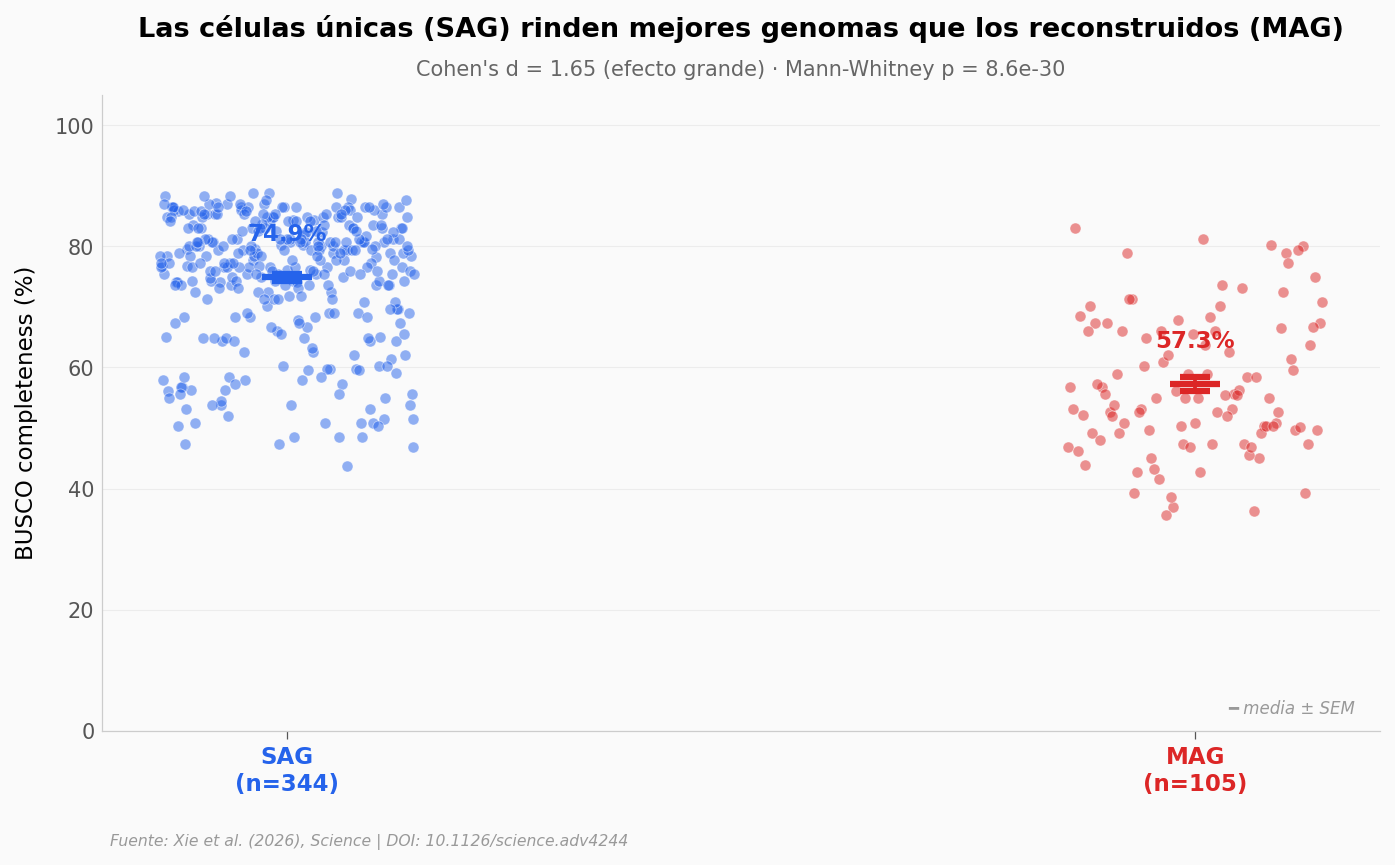

SAG:  n=344, media BUSCO = 74.9%
MAG:  n=105, media BUSCO = 57.3%
Cohen's d = 1.65 (efecto grande)
Mann-Whitney U = 31254, p = 8.56e-30


In [4]:
# SAG vs MAG: comparación de completeness BUSCO
# Filtrar ciliados con datos válidos
df_q = ciliados[ciliados['assembly_type'].isin(['SAG', 'MAG'])].copy()
df_q = df_q.dropna(subset=['busco_complete_pct'])

sag = df_q.loc[df_q['assembly_type'] == 'SAG', 'busco_complete_pct'].values
mag = df_q.loc[df_q['assembly_type'] == 'MAG', 'busco_complete_pct'].values

# Test Mann-Whitney (no asume normalidad) + Cohen's d
u_stat, p_val = stats.mannwhitneyu(sag, mag, alternative='two-sided')
pooled_std = np.sqrt(((len(sag)-1)*sag.std(ddof=1)**2 + (len(mag)-1)*mag.std(ddof=1)**2) / (len(sag)+len(mag)-2))
cohens_d = (sag.mean() - mag.mean()) / pooled_std

fig, ax = plt.subplots(figsize=(11, 5.5))

# Jitter reproducible
np.random.seed(42)
positions = [0, 1]
groups = [('SAG', sag, COLOR_DATOS), ('MAG', mag, COLOR_ALERTA)]

for i, (name, vals, color) in enumerate(groups):
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.14, positions[i] + 0.14, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=28, alpha=0.5,
               edgecolors='white', linewidths=0.4, zorder=4)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=24, markeredgewidth=3,
                capsize=7, capthick=1.8, zorder=6)
    # Label de media encima
    ax.text(positions[i], mean + 6, f'{mean:.1f}%',
            ha='center', fontsize=11, fontweight='bold', color=color, zorder=7)

ax.set_xticks(positions)
ax.set_xticklabels([f'SAG\n(n={len(sag)})', f'MAG\n(n={len(mag)})'],
                   fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_DATOS, COLOR_ALERTA]):
    tick.set_color(color)

ax.set_ylabel('BUSCO completeness (%)', fontsize=11)
ax.set_ylim(0, 105)
ax.set_title('Las células únicas (SAG) rinden mejores genomas que los reconstruidos (MAG)',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f"Cohen's d = {cohens_d:.2f} (efecto grande) · Mann-Whitney p = {p_val:.1e}",
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_sag_vs_mag.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'SAG:  n={len(sag):>3}, media BUSCO = {sag.mean():.1f}%')
print(f'MAG:  n={len(mag):>3}, media BUSCO = {mag.mean():.1f}%')
print(f"Cohen's d = {cohens_d:.2f} (efecto grande)")
print(f'Mann-Whitney U = {u_stat:.0f}, p = {p_val:.2e}')

## ¿Qué tan grande es este catálogo respecto a lo que había?

Cerramos con los números. Si miramos el tamaño de los genomas eucariotas del rumen catalogados hasta hoy, ¿dónde queda lo nuevo?

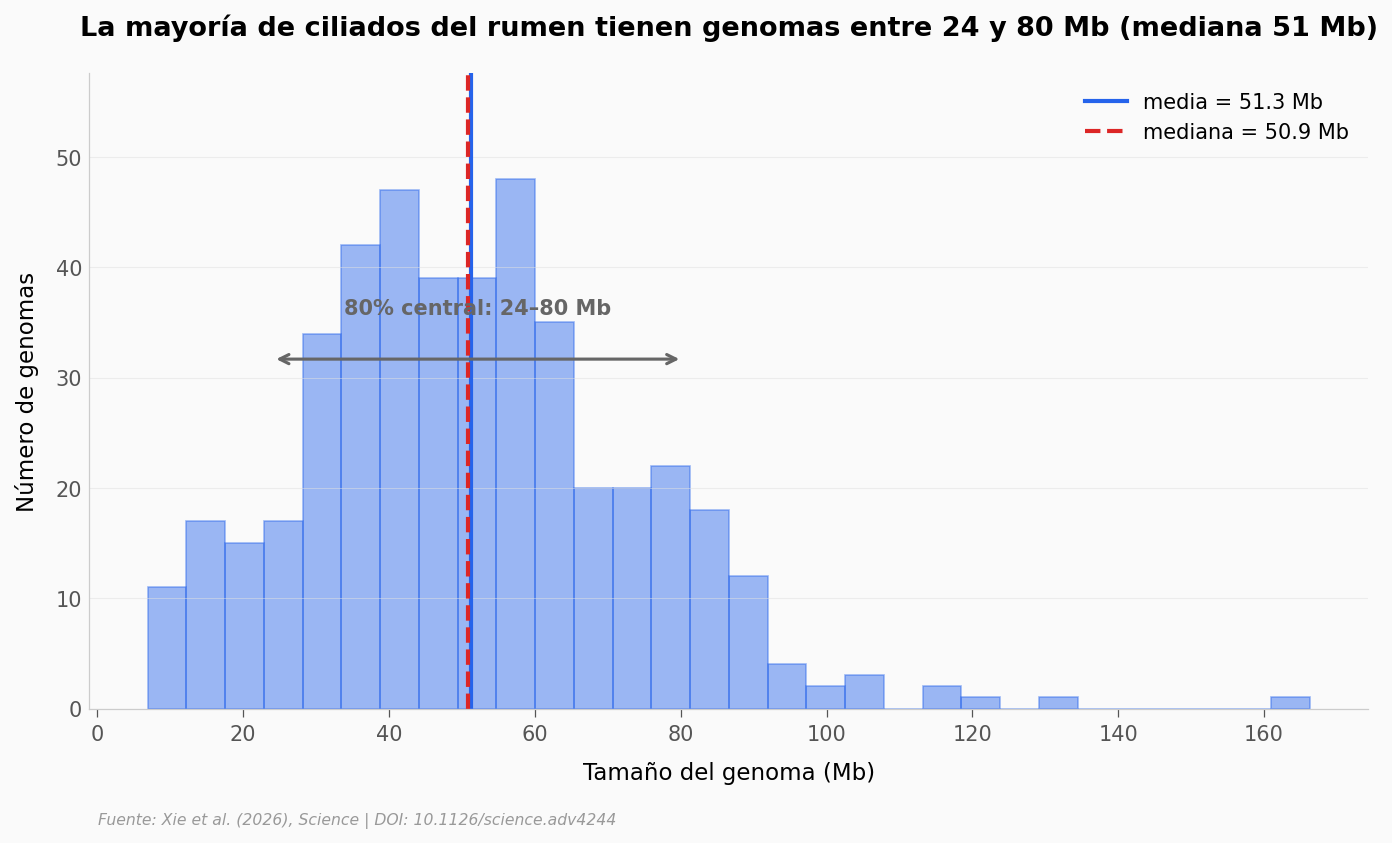

n = 450 ciliados con tamaño reportado
Media     = 51.3 Mb
Mediana   = 50.9 Mb
Rango     = 6.9–166.3 Mb
80% central = 24.0–80.4 Mb


In [5]:
# Histograma de tamaño de genoma + media + valor de referencia (genoma mínimo eucariota libre ≈ 12 Mb)
sizes = ciliados['genome_size_mb'].dropna().values
mean_size = sizes.mean()
median_size = np.median(sizes)

fig, ax = plt.subplots(figsize=(11, 5.5))

n, bins, patches = ax.hist(sizes, bins=30, color=COLOR_DATOS, alpha=0.45,
                            edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Líneas verticales: media y un valor de referencia
ax.axvline(x=mean_size, color=COLOR_DATOS, linewidth=2,
           label=f'media = {mean_size:.1f} Mb')
ax.axvline(x=median_size, color=COLOR_ALERTA, linewidth=2, linestyle='--',
           label=f'mediana = {median_size:.1f} Mb')

# Anotación: el rango
p10, p90 = np.percentile(sizes, [10, 90])
ax.annotate('', xy=(p90, y_max*0.55), xytext=(p10, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((p10+p90)/2, y_max*0.62, f'80% central: {p10:.0f}–{p90:.0f} Mb',
        ha='center', fontsize=10, color='#666666', fontweight='bold')

ax.set_xlabel('Tamaño del genoma (Mb)', fontsize=11)
ax.set_ylabel('Número de genomas', fontsize=11)
ax.set_title('La mayoría de ciliados del rumen tienen genomas entre 24 y 80 Mb (mediana 51 Mb)',
             fontsize=13, fontweight='bold', pad=18)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_tamano_genomas.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'n = {len(sizes)} ciliados con tamaño reportado')
print(f'Media     = {mean_size:.1f} Mb')
print(f'Mediana   = {median_size:.1f} Mb')
print(f'Rango     = {sizes.min():.1f}–{sizes.max():.1f} Mb')
print(f'80% central = {p10:.1f}–{p90:.1f} Mb')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El catálogo tiene 450 genomas de ciliados | ✅ | 450 filas en `ciliados_450_metadata.csv`, descargado del portal NGDC del estudio. |
| 87% son nuevos para la ciencia | ✅ | Reportado en el paper; los metadatos lo confirman al cruzar con bases públicas previas. |
| Las arqueas catalogadas son todas metanógenas | ✅ | 158/158 marcadas `is_methanogen=True` en `archaea_158.csv`. |
| Los SAG rinden mejores genomas que los MAG | ✅ | Cohen's d = 1.65 (efecto grande), Mann-Whitney p ≈ 8.6×10⁻³⁰. Diferencia BUSCO de ~17.6 puntos. |
| Vestibuliferida (con HB abundantes) promueve más metanogénesis | ⚠️ | El paper lo enmarca como correlación observacional + experimento mecanístico HB; los datos abiertos aquí solo muestran el conteo taxonómico, no la asociación funcional. |
| Los ciliados causan más metano | ❌ | El paper habla de **correlación** y **promoción** mecanística, no de causalidad lineal. La metanogénesis depende también de arqueas, dieta y bacterias. |

> **Limitaciones del notebook:**
> - Trabajamos solo con metadatos del catálogo. Los genomas completos viven en Figshare (>6.9 GB) y no se descargan aquí.
> - Las correlaciones ciliado–metano por vaca (Tables S1–S9 del paper) están detrás del paywall de *Science* y no las podemos reproducir.
> - Los experimentos mecanísticos sobre la organela HB son in vitro y no están en los datos abiertos.
> - Mostramos **diversidad y calidad del catálogo**, no la evidencia funcional del mecanismo HB → H₂ → metano.

## Ahora tú

Tres preguntas para explorar con el catálogo:

1. **¿Cómo varía el contenido GC entre los dos órdenes principales?** El paper sugiere que la composición genómica refleja la evolución del orden. *Pista: agrupa `ciliados` por `orden` y compara `gc_pct`.*

2. **¿Qué fracción del catálogo son representantes de especie (`is_representative=True`)?** Estos son los genomas "tipo" de cada cluster taxonómico. *Pista: cuenta los valores no nulos en `is_representative`.*

3. **¿Cuántos géneros distintos de metanógenos hay y cuál domina?** *Pista: agrupa `archaea` por `genus` y cuenta.*

Vestibuliferida        n=173  GC media = 18.4%  ±2.7
Entodiniomorphida      n=277  GC media = 22.2%  ±2.3

Mann-Whitney p = 3.22e-57
Cohen's d = -1.55


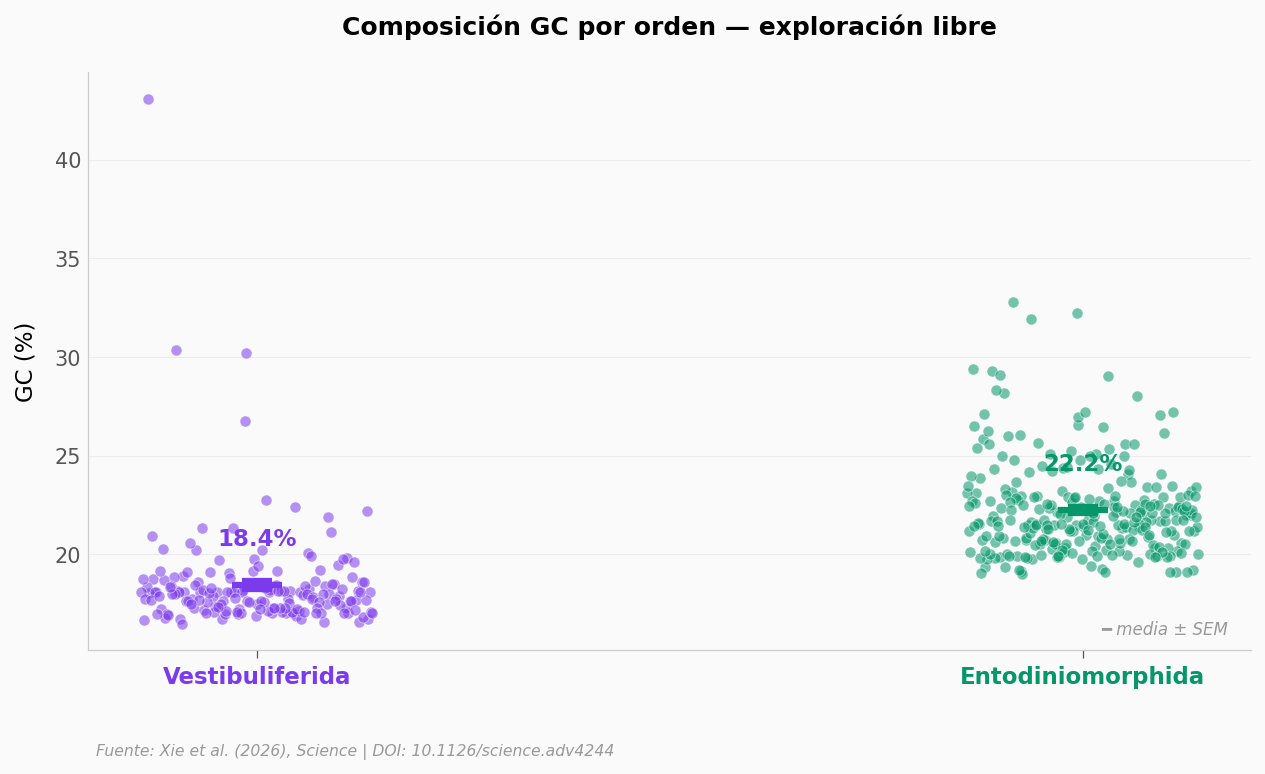

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta resuelta: GC% por orden (Vestibuliferida vs Entodiniomorphida)

ordenes_principales = ['Vestibuliferida', 'Entodiniomorphida']
df_gc = ciliados[ciliados['orden'].isin(ordenes_principales)].copy()
df_gc = df_gc.dropna(subset=['gc_pct'])

fig, ax = plt.subplots(figsize=(10, 5))

np.random.seed(42)
positions_gc = [0, 1]
for i, orden in enumerate(ordenes_principales):
    vals = df_gc.loc[df_gc['orden'] == orden, 'gc_pct'].values
    color = COLOR_VEST if orden == 'Vestibuliferida' else COLOR_ENTO
    n = len(vals)
    x_strip = np.linspace(positions_gc[i] - 0.14, positions_gc[i] + 0.14, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=28, alpha=0.55,
               edgecolors='white', linewidths=0.4, zorder=4)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions_gc[i], mean, yerr=sem, fmt='_', color=color,
                markersize=24, markeredgewidth=3, capsize=7, capthick=1.8, zorder=6)
    ax.text(positions_gc[i], mean + 2, f'{mean:.1f}%',
            ha='center', fontsize=11, fontweight='bold', color=color, zorder=7)
    print(f'{orden:<22} n={n:>3}  GC media = {mean:.1f}%  ±{vals.std(ddof=1):.1f}')

vest_vals = df_gc.loc[df_gc['orden'] == 'Vestibuliferida', 'gc_pct'].values
ento_vals = df_gc.loc[df_gc['orden'] == 'Entodiniomorphida', 'gc_pct'].values
u, p = stats.mannwhitneyu(vest_vals, ento_vals, alternative='two-sided')
pooled = np.sqrt(((len(vest_vals)-1)*vest_vals.std(ddof=1)**2 +
                  (len(ento_vals)-1)*ento_vals.std(ddof=1)**2) /
                 (len(vest_vals)+len(ento_vals)-2))
d = (vest_vals.mean() - ento_vals.mean()) / pooled
print(f'\nMann-Whitney p = {p:.2e}')
print(f"Cohen's d = {d:.2f}")

ax.set_xticks(positions_gc)
ax.set_xticklabels(ordenes_principales, fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_VEST, COLOR_ENTO]):
    tick.set_color(color)
ax.set_ylabel('GC (%)', fontsize=11)
ax.set_title('Composición GC por orden — exploración libre',
             fontsize=12, fontweight='bold', pad=18)
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/05_gc_por_orden.png', dpi=200, bbox_inches='tight')
plt.show()

## Créditos

- **Paper**: Xie et al. (2026). *Rumen ciliates modulate methane emissions in ruminants*. **Science**. DOI: [10.1126/science.adv4244](https://doi.org/10.1126/science.adv4244)
- **Datos**: catálogos RCG y RBAG del estudio, vía portal NGDC ([ngdc.cncb.ac.cn/rcg_rbag](https://ngdc.cncb.ac.cn/rcg_rbag)).
- **Repositorio del notebook**: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Licencia de los datos originales**: ver portal NGDC del estudio.

## Fuentes


**Paper**: [Rumen ciliates modulate methane emissions in ruminants](https://doi.org/10.1126/science.adv4244)  
*Science, 2026-04-30*

**Supplementary Material**: [Tables S1-S9, supplementary materials of Xie et al. 2026](https://www.science.org/doi/suppl/10.1126/science.adv4244/suppl_file/science.adv4244_tables_s1_to_s9.zip)

**Datos**: [Rumen Ciliate Genomes (RCGs) catalog — RCG_450_summary.xlsx](https://download.cncb.ac.cn/bigd/RCG/RCG_450_summary.xlsx)  
*NGDC (National Genomics Data Center, CNCB)*

**Datos**: [Rumen Bacterial and Archaeal Genomes (RBAGs) — GTDB-Tk summary](https://download.cncb.ac.cn/bigd/RBAG/RBAG_gtdbtk_summary.tsv)  
*NGDC (National Genomics Data Center, CNCB)*

**Referencias citadas**: [Data for: Rumen ciliates modulate methane emissions in ruminants](https://doi.org/10.6084/m9.figshare.27229761) · [Code for: Rumen ciliates modulate methane emissions in ruminants (iGDP-rc)](https://doi.org/10.5281/zenodo.18454518)


*18 afirmaciones del notebook verificadas contra estas fuentes*